In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
os.listdir()

['.ipynb_checkpoints', 'test', 'train', 'Untitled.ipynb']

In [3]:
# Get All Class Names in test
data_dir = "test"

classes = os.listdir(data_dir)

print("Number of classes:", len(classes))
print(classes)

Number of classes: 23
['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


In [4]:
# Get All Class Names in train
data_dir = "train"

classes = os.listdir(data_dir)

print("Number of classes:", len(classes))
print(classes)

Number of classes: 23
['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


In [5]:
# Count of Images in Each Class
data = []

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        data.append((cls, num_images))

df = pd.DataFrame(data, columns=["Class", "Images"])

df

,Class,Images
0,Acne and Rosacea Photos,840
1,Actinic Keratosis Basal Cell Carcinoma and oth...,1149
2,Atopic Dermatitis Photos,489
3,Bullous Disease Photos,448
4,Cellulitis Impetigo and other Bacterial Infect...,288
5,Eczema Photos,1235
6,Exanthems and Drug Eruptions,404
7,Hair Loss Photos Alopecia and other Hair Diseases,239
8,Herpes HPV and other STDs Photos,405
9,Light Diseases and Disorders of Pigmentation,568


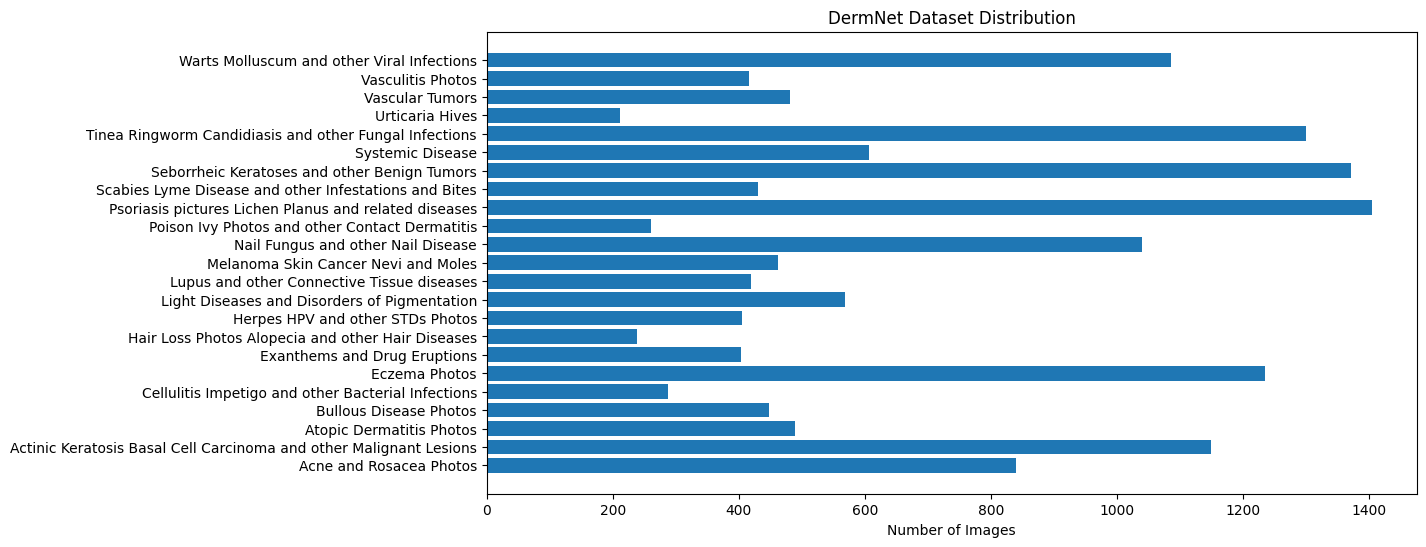

In [6]:
# Visualize Class Distribution
plt.figure(figsize=(12,6))

plt.barh(df["Class"], df["Images"])

plt.xlabel("Number of Images")
plt.title("DermNet Dataset Distribution")

plt.show()

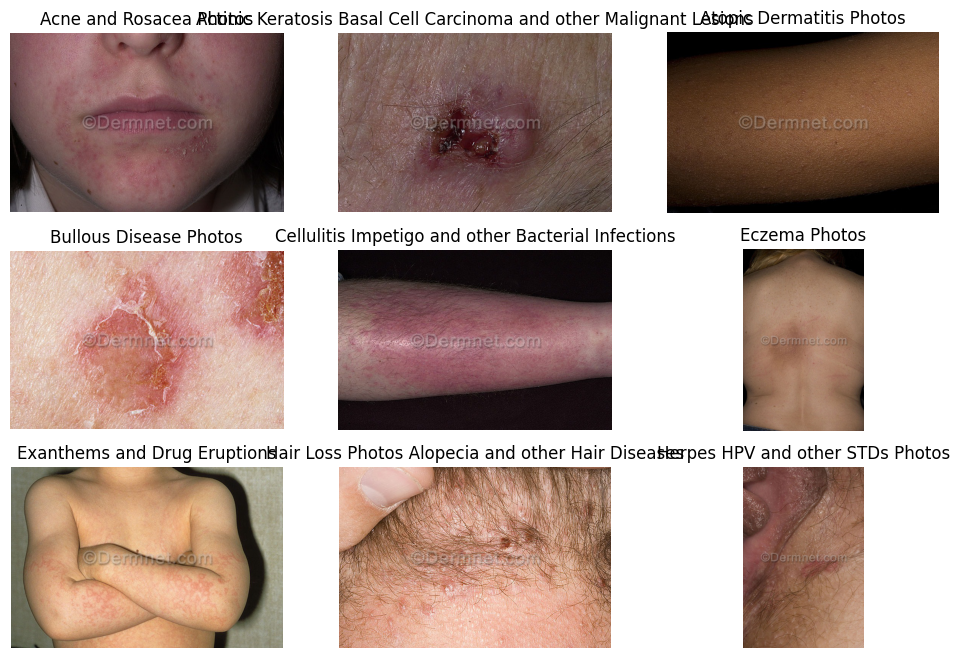

In [7]:
# Show Sample Images
from PIL import Image
import random
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes[:9]):
    
    folder = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [8]:
# Image size
from PIL import Image

img = Image.open(img_path)

print(img.size)

(480, 720)


In [9]:
#Image Shape
import numpy as np

img_array = np.array(img)

print(img_array.shape)

(720, 480, 3)


In [10]:
# Class Imbalance 
class_counts = {}

for cls in classes:
    path = os.path.join(data_dir,cls)
    class_counts[cls] = len(os.listdir(path))

df = pd.DataFrame(class_counts.items(), columns=["Class","Count"])
df = df.sort_values("Count",ascending=False)

df

,Class,Count
14,Psoriasis pictures Lichen Planus and related d...,1405
16,Seborrheic Keratoses and other Benign Tumors,1371
18,Tinea Ringworm Candidiasis and other Fungal In...,1300
5,Eczema Photos,1235
1,Actinic Keratosis Basal Cell Carcinoma and oth...,1149
22,Warts Molluscum and other Viral Infections,1086
12,Nail Fungus and other Nail Disease,1040
0,Acne and Rosacea Photos,840
17,Systemic Disease,606
9,Light Diseases and Disorders of Pigmentation,568


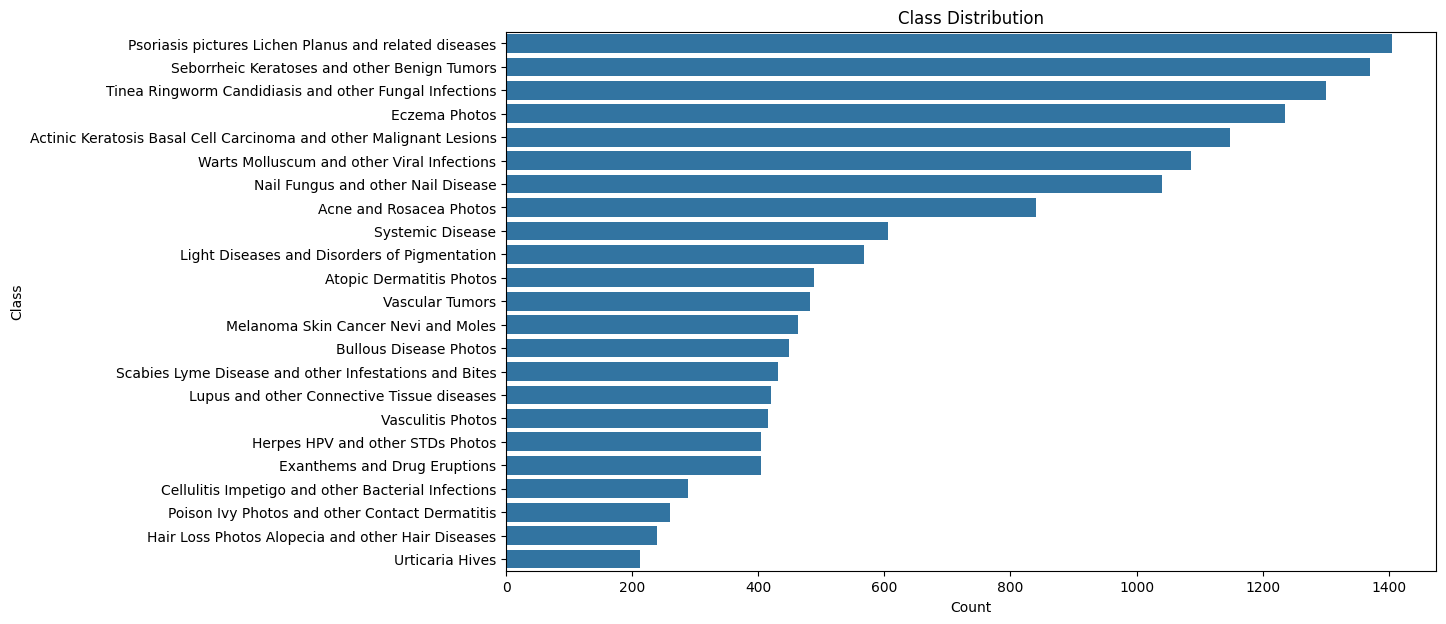

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

sns.barplot(data=df,y="Class",x="Count")

plt.title("Class Distribution")
plt.show()

In [12]:
# Image Resolution Distribution
from PIL import Image

widths = []
heights = []

for cls in classes:
    
    folder = os.path.join(data_dir,cls)
    
    for img_name in os.listdir(folder)[:200]:
        
        img_path = os.path.join(folder,img_name)
        
        img = Image.open(img_path)
        
        w,h = img.size
        
        widths.append(w)
        heights.append(h)

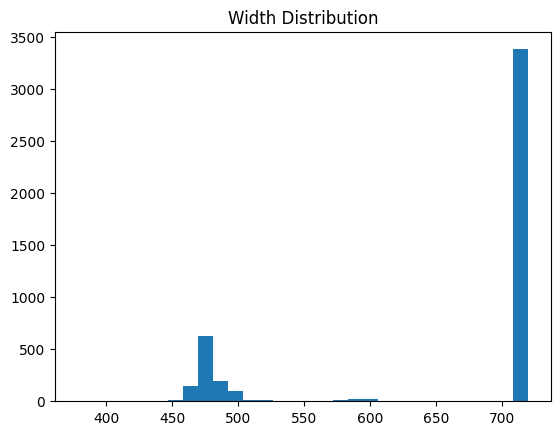

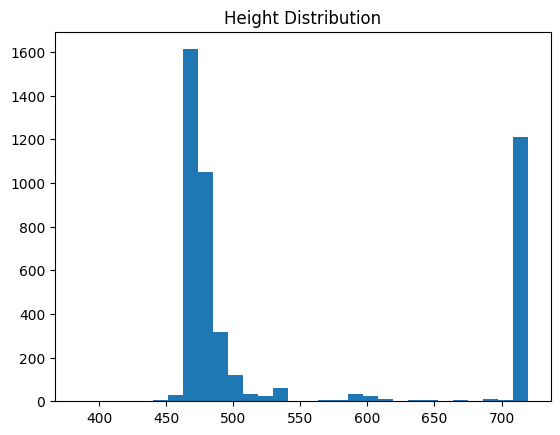

In [13]:
plt.hist(widths,bins=30)
plt.title("Width Distribution")
plt.show()

plt.hist(heights,bins=30)
plt.title("Height Distribution")
plt.show()

In [14]:
# Image Resolution Distribution
from PIL import Image

widths = []
heights = []

for cls in classes:
    
    folder = os.path.join(data_dir,cls)
    
    for img_name in os.listdir(folder)[:200]:
        
        img_path = os.path.join(folder,img_name)
        
        img = Image.open(img_path)
        
        w,h = img.size
        
        widths.append(w)
        heights.append(h)

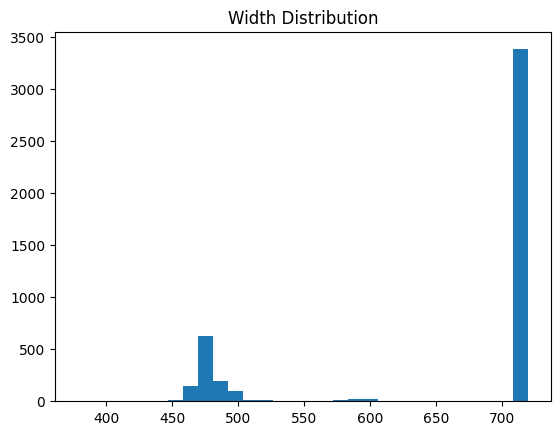

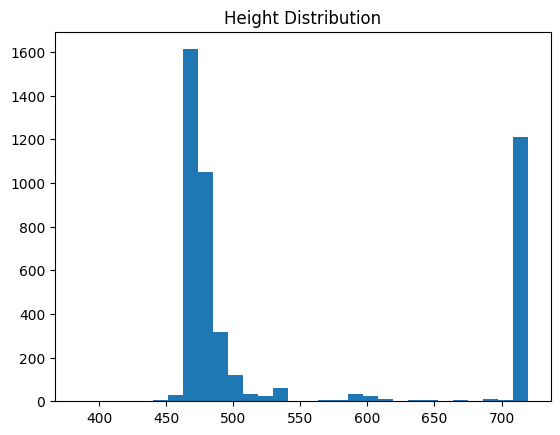

In [15]:
plt.hist(widths,bins=30)
plt.title("Width Distribution")
plt.show()

plt.hist(heights,bins=30)
plt.title("Height Distribution")
plt.show()

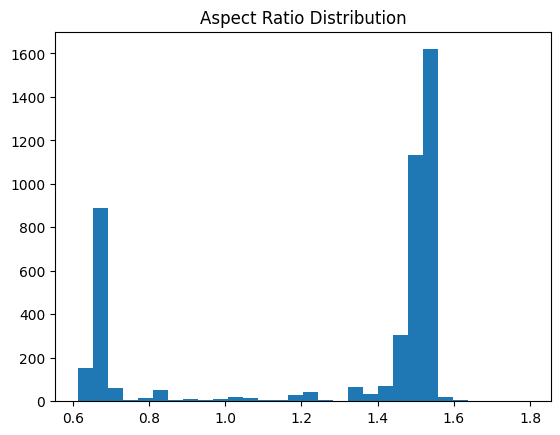

In [16]:
aspect_ratios = []

for w,h in zip(widths,heights):
    aspect_ratios.append(w/h)

plt.hist(aspect_ratios,bins=30)
plt.title("Aspect Ratio Distribution")
plt.show()

In [ ]:
# RGB Channel Analysis
r,g,b = [],[],[]

for cls in classes:
    folder = os.path.join(data_dir,cls)

    for img_name in os.listdir(folder)[:50]:

        img = np.array(Image.open(os.path.join(folder,img_name)))

        r.extend(img[:,:,0].flatten())
        g.extend(img[:,:,1].flatten())
        b.extend(img[:,:,2].flatten())

plt.hist(r,bins=50,alpha=0.5,label="Red")
plt.hist(g,bins=50,alpha=0.5,label="Green")
plt.hist(b,bins=50,alpha=0.5,label="Blue")

plt.legend()
plt.title("RGB Distribution")
plt.show()

In [ ]:
# Brightness Distribution
brightness = []

for cls in classes:

    folder = os.path.join(data_dir,cls)

    for img_name in os.listdir(folder)[:50]:

        img = np.array(Image.open(os.path.join(folder,img_name)))

        brightness.append(img.mean())

plt.hist(brightness,bins=30)

plt.title("Image Brightness")

plt.show()

In [ ]:
# Pixel Intensity Distribution
pixels = []

for cls in classes:

    folder = os.path.join(data_dir,cls)

    for img_name in os.listdir(folder)[:30]:

        img = np.array(Image.open(os.path.join(folder,img_name)))

        pixels.extend(img.flatten())

plt.hist(pixels,bins=50)

plt.title("Pixel Distribution")

plt.show()